In [2]:
import qutip as qt
import numpy as np
import scipy as sp
import matplotlib
import matplotlib.pyplot as plt
#plt.rcParams['text.usetex'] = True
#rfont = {'fontname':'Times New Roman'}
matplotlib.rcParams.update(matplotlib.rcParamsDefault)

from scipy.optimize import linear_sum_assignment
from itertools import combinations

# Spin matrix
S0 = qt.qeye(3)                                                # {1, 0, -1}
Sx, Sy, Sz = qt.jmat(1)                                        # {1, 0, -1}
sigma0 = qt.qeye(2)                                            # {Ex, Ey}
sigmax, sigmay, sigmaz = qt.sigmax(), qt.sigmay(), qt.sigmaz() # {Ex, Ey}

In [3]:
# Physics constant
h             = 6.626e-34        # J/Hz
muB           = 9.274e-24 / h    # Hz/T           # GHz/T
Des_para      = 1425e6           # Hz       # [Doherty 2013], 1425e6[Fuchs] 
# lambdaes_para = 5.3e9            # Hz       # [Doherty 2013], 5.33e9[Bassett 2014]
# lambdaes_perp = 0.2e9/np.sqrt(2) # Hz       # [Doherty 2013]
des_para      = 6e3              # Hz/(V/m) # [Doherty 2013]?
# des_perp      = 6e3              # Hz/(V/m) # [Doherty 2013]?
# les_para      = 0.1              # 1        # [Doherty 2013], 0.05[Bassett 2014] at 1.5K
ges_para      = 2.01             # 1        # [Doherty 2013], 2.15[Bassett 2014]
# ges_perp      = 2.01             # 1        # [Doherty 2013]
gamma_e       = muB*ges_para     # 28GHz/T  

In [7]:
# bare Hamiltonian
H_RTes = Des_para * (Sz**2 - 2/3 * S0)

# Interaction Hamiltonian
def V_RTes(E, B, deltaz, deltaxi):
    return des_para * (E[2] + deltaz) * S0 \
           + muB *ges_para * (Sx*B[0] + Sy*B[1] + Sz*B[2]) \
           + deltaxi * (Sy**2 - Sx**2)

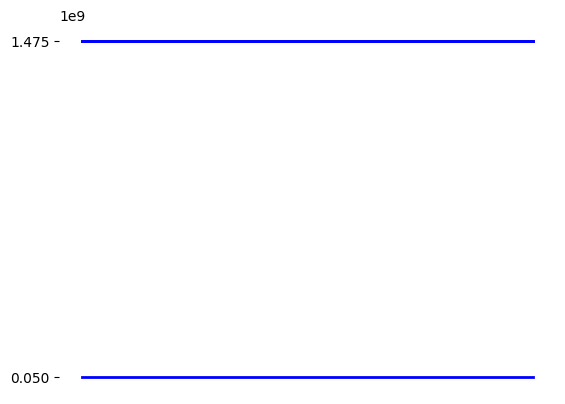

In [10]:
# plot energy levels
E = [0, 0, 0] # V/m
B = [0, 0, 0] # T
delta = 1e9/des_para# Hz

H_tot = H_RTes + V_RTes(E, B, delta, 0)
qt.plot_energy_levels([H_tot], h_labels=None, energy_levels=None, N=0, fig=None, ax=None) #qutip 5.0
#qt.plot_energy_levels([H_tot], show_ylabels=True, figsize=(2, 3)) #qutip 4.0


plt.show()

In [ ]:
# Bz list
Bz = np.linspace(0e-4, 5000e-4) #[T]  1Gauss = 1e-4T
# value=6
deltaz = 0e9/ des_para #deltax deltay ともに0
Bx=By=0*1e-4
deltaxi = 70e6 #Hz

# eigenvalues
ee_Bz = [(H_RTes + V_RTes(E=[0, 0, 0], B=[Bx, By, Bzi], deltaz, deltaxi)).eigenenergies() for Bzi in Bz]

plt.figure(figsize=(5, 5))
for i in reversed(range(6)):
    plt.plot(
        Bz * 1e3,
        [ee[i] / 1e9 for ee in ee_Bz]
        # label=labels[i],
        # color=colors[i]
    )


plt.xlabel(f"Magnetic field $B_z$ (mT)")
plt.ylabel(r"Energy $E$ (GHz)")
#plt.ylim(-55, -45)
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), borderaxespad=0)  # 凡例を外に
plt.tight_layout()
plt.show()